# Curso 2, Semana 1 — Regularización L2 y Dropout
### Kevin Vargas Flores

En esta práctica se conserva la nomenclatura de la red profunda anterior: ejemplos por columnas, parámetros `W1`, `b1`, ..., cachés por capa, ReLU en las capas ocultas y sigmoide en la salida.

## Objetivos

1. Reconocer el sobreajuste mediante la brecha entrenamiento–validación.
2. Implementar regularización L2 en el costo y en los gradientes.
3. Implementar dropout invertido en propagación hacia adelante y hacia atrás.
4. Transferir el procedimiento a otro conjunto de datos y otra arquitectura.

> Una regularización adecuada puede reducir la exactitud de entrenamiento y, al mismo tiempo, mejorar la generalización.


In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split

SEED = 42
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True})


## Ejercicio 1. Comparación controlada con `make_moons`

Se utilizará una red deliberadamente amplia y pocos ejemplos de entrenamiento para hacer visible el sobreajuste. Los conjuntos de validación y prueba no participan en el aprendizaje de los parámetros.


train: (2, 270) dev: (2, 315) test: (2, 315)


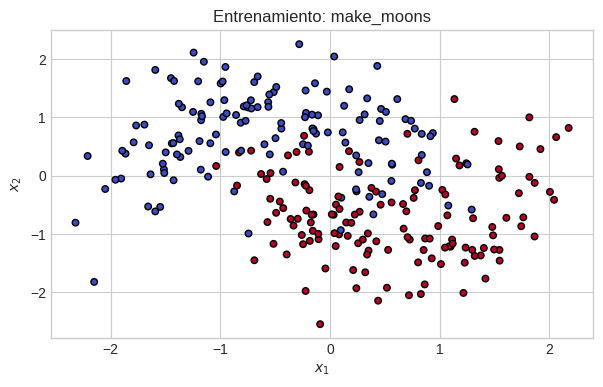

In [52]:
def prepare_data(X_raw, y_raw, train_size=0.30, seed=SEED):
    X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(
        X_raw, y_raw, train_size=train_size, stratify=y_raw, random_state=seed
    )
    X_dev_raw, X_test_raw, y_dev_raw, y_test_raw = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=seed
    )

    # La normalización se calcula únicamente con entrenamiento.
    mu = X_train_raw.mean(axis=0, keepdims=True)
    sigma = X_train_raw.std(axis=0, keepdims=True)

    def transform(X, y):
        return ((X - mu) / sigma).T, y.reshape(1, -1)

    return (*transform(X_train_raw, y_train_raw),
            *transform(X_dev_raw, y_dev_raw),
            *transform(X_test_raw, y_test_raw))


X_raw, y_raw = make_moons(n_samples=900, noise=0.32, random_state=SEED)
X_train, Y_train, X_dev, Y_dev, X_test, Y_test = prepare_data(X_raw, y_raw)

print("train:", X_train.shape, "dev:", X_dev.shape, "test:", X_test.shape)
plt.scatter(X_train[0], X_train[1], c=Y_train.ravel(),
            cmap="coolwarm", edgecolor="k", s=22)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("Entrenamiento: make_moons")
plt.show()


### Regularización L2

L2 modifica el objetivo y el gradiente:

$$J_{L2}=J_{datos}+\frac{\lambda}{2m}\sum_{l=1}^{L}\|W^{[l]}\|_F^2,$$

$$dW^{[l]}=dW_{backprop}^{[l]}+\frac{\lambda}{m}W^{[l]}.$$

No se regularizan los sesgos.

### Dropout invertido

En cada capa oculta:

$$D^{[l]}\sim\operatorname{Bernoulli}(keep\_prob),$$

$$\widetilde A^{[l]}=\frac{A^{[l]}\odot D^{[l]}}{keep\_prob}.$$

En el backward se reutiliza exactamente la misma máscara. Dropout se desactiva durante validación, prueba y predicción.


In [53]:
def sigmoid(Z):
    Z = np.clip(Z, -500, 500)
    return 1 / (1 + np.exp(-Z))


def binary_cross_entropy(AL, Y):
    AL = np.clip(AL, 1e-12, 1 - 1e-12)
    return float(-np.mean(Y * np.log(AL) + (1 - Y) * np.log(1 - AL)))


def initialize_he(layer_dims, seed=SEED):
    rng = np.random.default_rng(seed)
    params = {}
    for l in range(1, len(layer_dims)):
        n_out, n_in = layer_dims[l], layer_dims[l - 1]
        params[f"W{l}"] = rng.standard_normal((n_out, n_in)) * np.sqrt(2 / n_in)
        params[f"b{l}"] = np.zeros((n_out, 1))
    return params


## Implementación de L2 y dropout


In [54]:
def l2_penalty(params, m, lambd):
    weights = (value for key, value in params.items() if key.startswith("W"))
    return lambd * sum(np.sum(W**2) for W in weights) / (2 * m)


def L_model_forward(X, params, keep_prob=1.0, training=False, rng=None):
    if not 0 < keep_prob <= 1:
        raise ValueError("keep_prob debe pertenecer a (0, 1]")
    if rng is None:
        rng = np.random.default_rng(SEED)

    A, caches = X, []
    L = len(params) // 2

    for l in range(1, L):
        A_prev = A
        W, b = params[f"W{l}"], params[f"b{l}"]
        Z = W @ A_prev + b
        A = np.maximum(0, Z)

        D = None
        if training and keep_prob < 1:
            D = rng.random(A.shape) < keep_prob
            A = A * D / keep_prob

        caches.append({"A_prev": A_prev, "W": W, "Z": Z, "D": D})

    A_prev = A
    W, b = params[f"W{L}"], params[f"b{L}"]
    Z = W @ A_prev + b
    AL = sigmoid(Z)
    caches.append({"A_prev": A_prev, "W": W, "Z": Z, "D": None})
    return AL, caches


def L_model_backward(AL, Y, caches, lambd=0.0, keep_prob=1.0):
    grads = {}
    m, L = Y.shape[1], len(caches)

    cache = caches[-1]
    dZ = AL - Y

    grads[f"dW{L}"] = (dZ @ cache["A_prev"].T / m
                        + lambd * cache["W"] / m)
    grads[f"db{L}"] = np.sum(dZ, axis=1, keepdims=True) / m
    dA = cache["W"].T @ dZ

    for l in reversed(range(1, L)):
        cache = caches[l - 1]

        if cache["D"] is not None:
            dA = dA * cache["D"] / keep_prob

        dZ = dA * (cache["Z"] > 0)
        grads[f"dW{l}"] = (dZ @ cache["A_prev"].T / m
                            + lambd * cache["W"] / m)
        grads[f"db{l}"] = np.sum(dZ, axis=1, keepdims=True) / m
        dA = cache["W"].T @ dZ

    return grads


In [55]:
def update_parameters_deep(params, grads, learning_rate):
    L = len(params) // 2
    for l in range(1, L + 1):
        params[f"W{l}"] -= learning_rate * grads[f"dW{l}"]
        params[f"b{l}"] -= learning_rate * grads[f"db{l}"]
    return params


def predict_deep(params, X):
    AL, _ = L_model_forward(X, params, training=False)
    return (AL >= 0.5).astype(int)


def accuracy(params, X, Y):
    return 100 * np.mean(predict_deep(params, X) == Y)


def total_weight_norm(params):
    return np.sqrt(sum(np.sum(value**2)
                       for key, value in params.items()
                       if key.startswith("W")))


def train_regularized(X_train, Y_train, layer_dims, lambd=0.0,
                      keep_prob=1.0, iterations=6500,
                      learning_rate=0.03, seed=SEED):
    params = initialize_he(layer_dims, seed)
    rng = np.random.default_rng(seed)
    history = {"data_loss": [], "objective": []}

    for i in range(iterations):
        AL, caches = L_model_forward(
            X_train, params, keep_prob=keep_prob,
            training=(keep_prob < 1), rng=rng
        )
        data_loss = binary_cross_entropy(AL, Y_train)
        objective = data_loss + l2_penalty(params, Y_train.shape[1], lambd)
        grads = L_model_backward(
            AL, Y_train, caches, lambd=lambd, keep_prob=keep_prob
        )
        params = update_parameters_deep(params, grads, learning_rate)

        if i % 100 == 0:
            history["data_loss"].append(data_loss)
            history["objective"].append(objective)

    return params, history


### Experimento controlado

Solo cambia la técnica de regularización. Se mantienen fijos los datos, la arquitectura, la inicialización, la tasa de aprendizaje y el número de iteraciones.


Sin regularización train= 93.33%  dev= 87.94%  brecha= 5.40 pp  ||W||= 15.02
L2                 train= 90.74%  dev= 90.16%  brecha= 0.58 pp  ||W||=  6.78
Dropout            train= 92.22%  dev= 88.57%  brecha= 3.65 pp  ||W||= 14.20


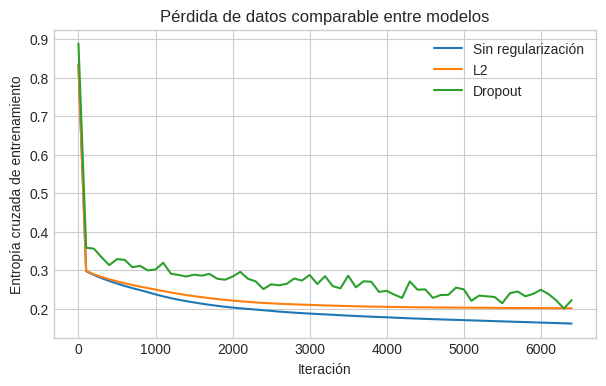

In [56]:
layer_dims = [2, 60, 40, 20, 1]
settings = {
    "Sin regularización": {"lambd": 0.0, "keep_prob": 1.0},
    "L2":                 {"lambd": 1.5, "keep_prob": 1.0},
    "Dropout":            {"lambd": 0.0, "keep_prob": 0.80},
}

models, histories = {}, {}

for name, cfg in settings.items():
    models[name], histories[name] = train_regularized(
        X_train, Y_train, layer_dims, **cfg
    )

    train_acc = accuracy(models[name], X_train, Y_train)
    dev_acc = accuracy(models[name], X_dev, Y_dev)
    print(f"{name:18s} train={train_acc:6.2f}%  dev={dev_acc:6.2f}%  "
          f"brecha={train_acc-dev_acc:5.2f} pp  "
          f"||W||={total_weight_norm(models[name]):6.2f}")

for name, history in histories.items():
    steps = np.arange(len(history["data_loss"])) * 100
    plt.plot(steps, history["data_loss"], label=name)

plt.xlabel("Iteración")
plt.ylabel("Entropía cruzada de entrenamiento")
plt.title("Pérdida de datos comparable entre modelos")
plt.legend()
plt.show()


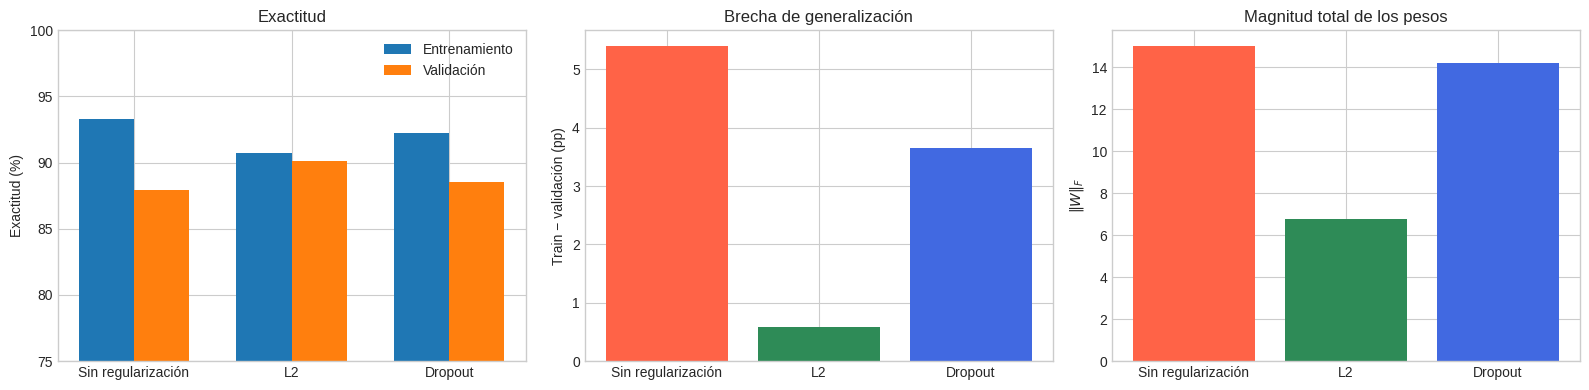

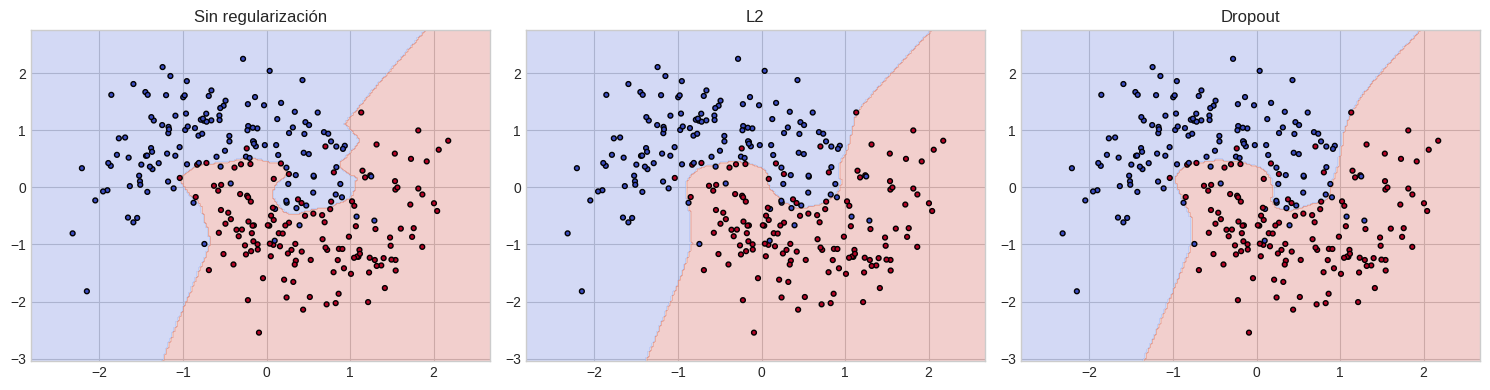

In [57]:
names = list(models)
train_scores = [accuracy(models[n], X_train, Y_train) for n in names]
dev_scores = [accuracy(models[n], X_dev, Y_dev) for n in names]
gaps = [train_scores[i] - dev_scores[i] for i in range(len(names))]
weight_norms = [total_weight_norm(models[n]) for n in names]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
x = np.arange(len(names)); width = 0.35

axes[0].bar(x-width/2, train_scores, width, label="Entrenamiento")
axes[0].bar(x+width/2, dev_scores, width, label="Validación")
axes[0].set_xticks(x); axes[0].set_xticklabels(names)
axes[0].set_ylabel("Exactitud (%)"); axes[0].set_ylim(75, 100)
axes[0].set_title("Exactitud"); axes[0].legend()

axes[1].bar(names, gaps, color=["tomato", "seagreen", "royalblue"])
axes[1].set_ylabel("Train − validación (pp)")
axes[1].set_title("Brecha de generalización")

axes[2].bar(names, weight_norms, color=["tomato", "seagreen", "royalblue"])
axes[2].set_ylabel(r"$\Vert W\Vert_F$")
axes[2].set_title("Magnitud total de los pesos")

plt.tight_layout(); plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x1 = np.linspace(X_train[0].min()-0.5, X_train[0].max()+0.5, 220)
x2 = np.linspace(X_train[1].min()-0.5, X_train[1].max()+0.5, 220)
xx, yy = np.meshgrid(x1, x2)
grid = np.vstack([xx.ravel(), yy.ravel()])

for ax, (name, params) in zip(axes, models.items()):
    zz = predict_deep(params, grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.25, cmap="coolwarm")
    ax.scatter(X_train[0], X_train[1], c=Y_train.ravel(),
               cmap="coolwarm", edgecolor="k", s=12)
    ax.set_title(name)

plt.tight_layout(); plt.show()


### Selección y evaluación final

El conjunto de prueba se consulta una sola vez, después de seleccionar el modelo con validación.


In [58]:
best_name = max(models, key=lambda name: accuracy(models[name], X_dev, Y_dev))
best_model = models[best_name]
print("Modelo seleccionado con validación:", best_name)
print(f"Exactitud final en prueba: {accuracy(best_model, X_test, Y_test):.2f}%")


Modelo seleccionado con validación: L2
Exactitud final en prueba: 88.89%


### Preguntas de análisis

1. ¿Qué evidencia indica que el modelo sin regularización presenta sobreajuste?

Tres cosas:
  
- La diferencia que se encuentra entre el modelo de entrenamiento y el modelo de desarrollo o prueba. Esta de 5.40, la diferencia más alta de los 3 modelos.

- Frontera de decisión compleja, ya que la del modelo sin normalizar se mira como que quisiera adaptarse para separar todos los puntos segun su distribución
  
- La norma de los pesos es muy grande 15.02, esto nos dice que el modelo reacciona de manera exagerada a los valores de entrada

2. ¿Por qué L2 reduce la norma $\Vert W\Vert_F$?

Para minimizar el costo total, el algoritmo de optimización no solo debe reducir el error de clasificación, sino también mantener los pesos lo más cercanos a cero posible.

3. ¿Por qué dropout se desactiva durante validación y prueba?

Porque este algoritmo o paradigma se utiliza unicamente cuando se esta entrenando el modelo ya que a la "hora de la verdad" tendriamos que realmente utilizar todas las neuronas que tengamos disponibles, que aproveche el poder de la red completa con todas sus conexiones aprendidas.

4. ¿Por qué una exactitud de entrenamiento menor no implica necesariamente un peor modelo?

Lo que se busca es que el modelo pueda generalizar y NO memorizar, es por ello que el error es normal, incluso en humanos este error debe de existir este sesgo que nos permita fallar.

## Ejercicio 2. Transferencia a `make_circles`

Ahora se utiliza otro conjunto de datos y una arquitectura diferente. La selección de hiperparámetros debe hacerse con validación; prueba se utiliza únicamente al final.


train: (2, 90) dev: (2, 255) test: (2, 255)


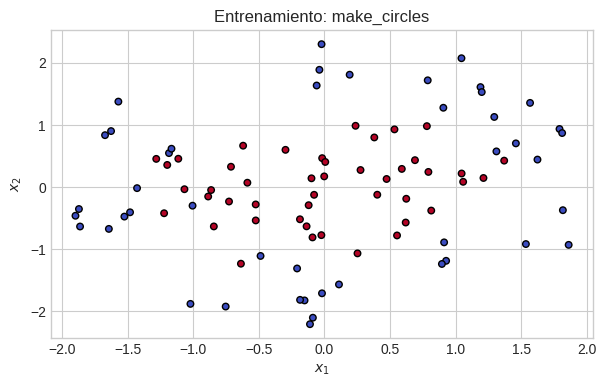

In [59]:
X_raw, y_raw = make_circles(
    n_samples=600, noise=0.18, factor=0.45, random_state=SEED
)

X_train, Y_train, X_dev, Y_dev, X_test, Y_test = prepare_data(
    X_raw, y_raw, train_size=0.15
)

print("train:", X_train.shape, "dev:", X_dev.shape, "test:", X_test.shape)
plt.scatter(X_train[0], X_train[1], c=Y_train.ravel(),
            cmap="coolwarm", edgecolor="k", s=22)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("Entrenamiento: make_circles")
plt.show()


Sin regularización train= 98.89%  dev= 83.92%  brecha=14.97 pp  ||W||= 15.15
L2                 train= 94.44%  dev= 90.20%  brecha= 4.25 pp  ||W||=  4.47
Dropout            train= 96.67%  dev= 85.88%  brecha=10.78 pp  ||W||= 14.24


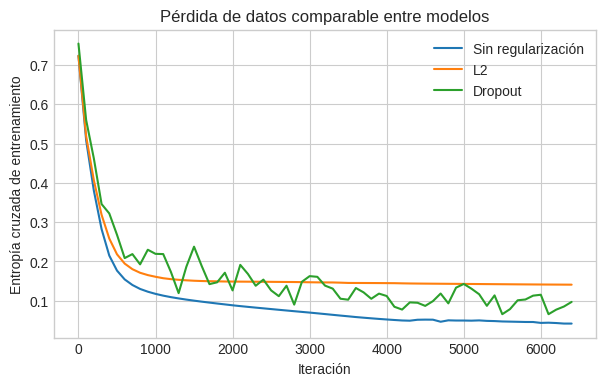

In [60]:
# Segunda arquitectura: distinta de la utilizada con make_moons.
layer_dims = [2, 64, 32, 16, 1]

# Configuraciones seleccionadas usando únicamente validación.
settings = {
    "Sin regularización": {"lambd": 0.0, "keep_prob": 1.0},
    "L2":                 {"lambd": 1.5, "keep_prob": 1.0},
    "Dropout":            {"lambd": 0.0, "keep_prob": 0.90},
}

models, histories = {}, {}

for name, cfg in settings.items():
    models[name], histories[name] = train_regularized(
        X_train, Y_train, layer_dims, **cfg
    )

    train_acc = accuracy(models[name], X_train, Y_train)
    dev_acc = accuracy(models[name], X_dev, Y_dev)
    print(f"{name:18s} train={train_acc:6.2f}%  dev={dev_acc:6.2f}%  "
          f"brecha={train_acc-dev_acc:5.2f} pp  "
          f"||W||={total_weight_norm(models[name]):6.2f}")

for name, history in histories.items():
    steps = np.arange(len(history["data_loss"])) * 100
    plt.plot(steps, history["data_loss"], label=name)

plt.xlabel("Iteración")
plt.ylabel("Entropía cruzada de entrenamiento")
plt.title("Pérdida de datos comparable entre modelos")
plt.legend()
plt.show()


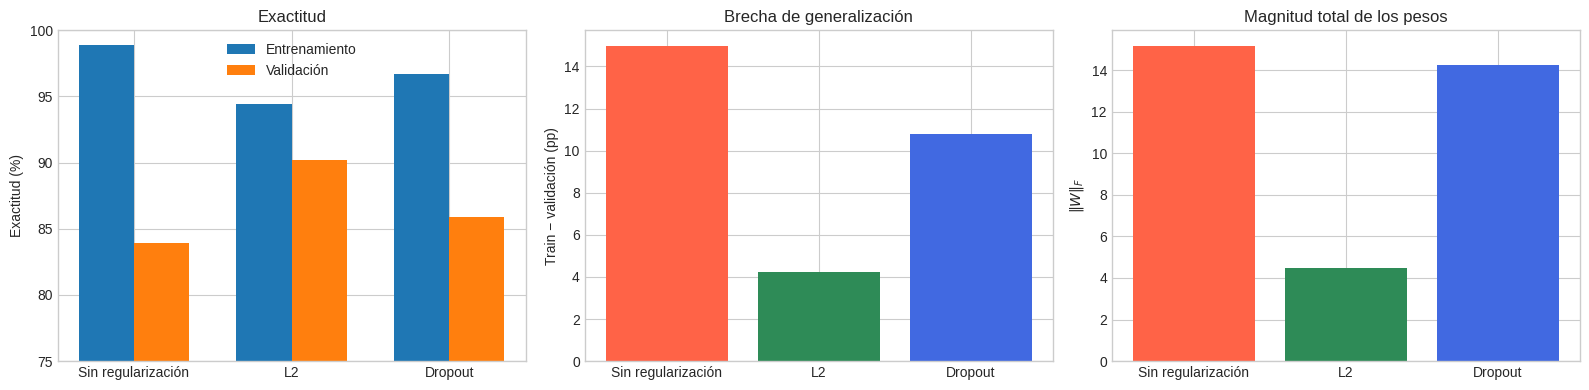

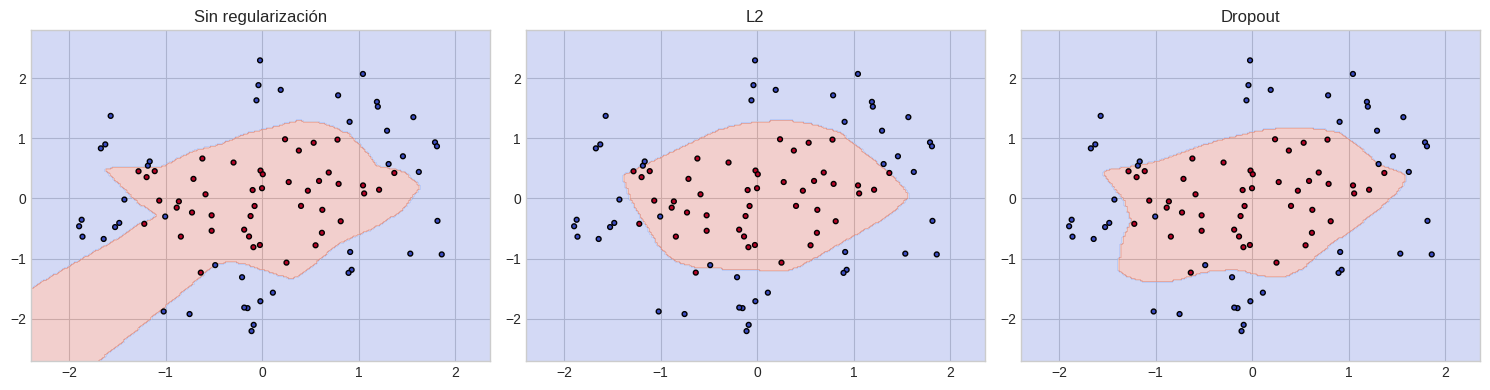

In [61]:
names = list(models)
train_scores = [accuracy(models[n], X_train, Y_train) for n in names]
dev_scores = [accuracy(models[n], X_dev, Y_dev) for n in names]
gaps = [train_scores[i] - dev_scores[i] for i in range(len(names))]
weight_norms = [total_weight_norm(models[n]) for n in names]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
x = np.arange(len(names)); width = 0.35

axes[0].bar(x-width/2, train_scores, width, label="Entrenamiento")
axes[0].bar(x+width/2, dev_scores, width, label="Validación")
axes[0].set_xticks(x); axes[0].set_xticklabels(names)
axes[0].set_ylabel("Exactitud (%)"); axes[0].set_ylim(75, 100)
axes[0].set_title("Exactitud"); axes[0].legend()

axes[1].bar(names, gaps, color=["tomato", "seagreen", "royalblue"])
axes[1].set_ylabel("Train − validación (pp)")
axes[1].set_title("Brecha de generalización")

axes[2].bar(names, weight_norms, color=["tomato", "seagreen", "royalblue"])
axes[2].set_ylabel(r"$\Vert W\Vert_F$")
axes[2].set_title("Magnitud total de los pesos")

plt.tight_layout(); plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x1 = np.linspace(X_train[0].min()-0.5, X_train[0].max()+0.5, 220)
x2 = np.linspace(X_train[1].min()-0.5, X_train[1].max()+0.5, 220)
xx, yy = np.meshgrid(x1, x2)
grid = np.vstack([xx.ravel(), yy.ravel()])

for ax, (name, params) in zip(axes, models.items()):
    zz = predict_deep(params, grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.25, cmap="coolwarm")
    ax.scatter(X_train[0], X_train[1], c=Y_train.ravel(),
               cmap="coolwarm", edgecolor="k", s=12)
    ax.set_title(name)

plt.tight_layout(); plt.show()


In [62]:
best_name = max(models, key=lambda name: accuracy(models[name], X_dev, Y_dev))
best_model = models[best_name]
print("Modelo seleccionado con validación:", best_name)
print(f"Exactitud final en prueba: {accuracy(best_model, X_test, Y_test):.2f}%")


Modelo seleccionado con validación: L2
Exactitud final en prueba: 91.76%


### Conclusiones

- El modelo sin regularización funciona como línea base.
- L2 controla directamente la magnitud de los pesos.
- Dropout entrena subredes distintas y reduce la dependencia entre neuronas.
- El mejor modelo se decide por validación, no por la exactitud de entrenamiento ni por prueba.


# Práctica integral de evaluación: regularización aplicada a un conjunto de datos real para la clasificación binaria.

El propósito principal no es solamente obtener una exactitud elevada, sino construir, identificar y explicar correctamente el **pipeline completo de aprendizaje profundo** que hemos estudiado.

## Actividades

1. Describir el dataset, sus variables, clases, distribución y posibles valores faltantes.
2. Dividir los datos de forma estratificada en entrenamiento, validación y prueba.
3. Calcular la media y desviación estándar únicamente con entrenamiento y utilizarlas para normalizar los tres conjuntos.
4. Comparar al menos tres arquitecturas:

| Arquitectura | Capas |
|---|---|
| Pequeña | `[n_x,16,8,1]` |
| Mediana | `[n_x,64,32,16,1]` |
| Amplia | `[n_x,128,64,32,1]` |

5. Utilizar inicialización He, ReLU en las capas ocultas, sigmoide en la salida y entropía cruzada binaria.
6. Entrenar y comparar:
   - modelo sin regularización;
   - modelo con L2;
   - modelo con dropout.
7. Seleccionar `lambda` y `keep_prob` utilizando únicamente validación.
8. Evaluar una sola vez en prueba el modelo seleccionado.
9. Identificar y explicar en el código:
   - normalización sin fuga de información;
   - inicialización He;
   - penalización L2 en el costo;
   - contribución de L2 en los gradientes;
   - dropout en forward y backward;
   - desactivación de dropout durante validación y prueba.



## 0. Importación del Dataset

In [63]:

"No encontre un dataset de mi interes e intente hacerlo con un dataset propio"
!git clone https://github.com/kao05/Deep-Learning
import os
import pandas as pd
archivos_data = os.listdir('Deep-Learning/Data')
print("Archivos en la carpeta data:", archivos_data)
df = pd.read_csv('Deep-Learning/Data/Churn.csv')


fatal: destination path 'Deep-Learning' already exists and is not an empty directory.
Archivos en la carpeta data: ['Churn.csv', 'README.md']


In [64]:
#@title Librerias y primera visualizacion del dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print(df.shape)
df.info()
df.head()


(10000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64 

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## 1. Descripción del dataset

/tmp/ipykernel_1615/2129519594.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Geography', ax=axes[0, 2], palette='Blues_d')
/tmp/ipykernel_1615/2129519594.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Gender', ax=axes[0, 3], palette='Pastel1')
/tmp/ipykernel_1615/2129519594.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Tenure', ax=axes[1, 1], palette='crest')
/tmp/ipykernel_1615/2129519594.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is depre

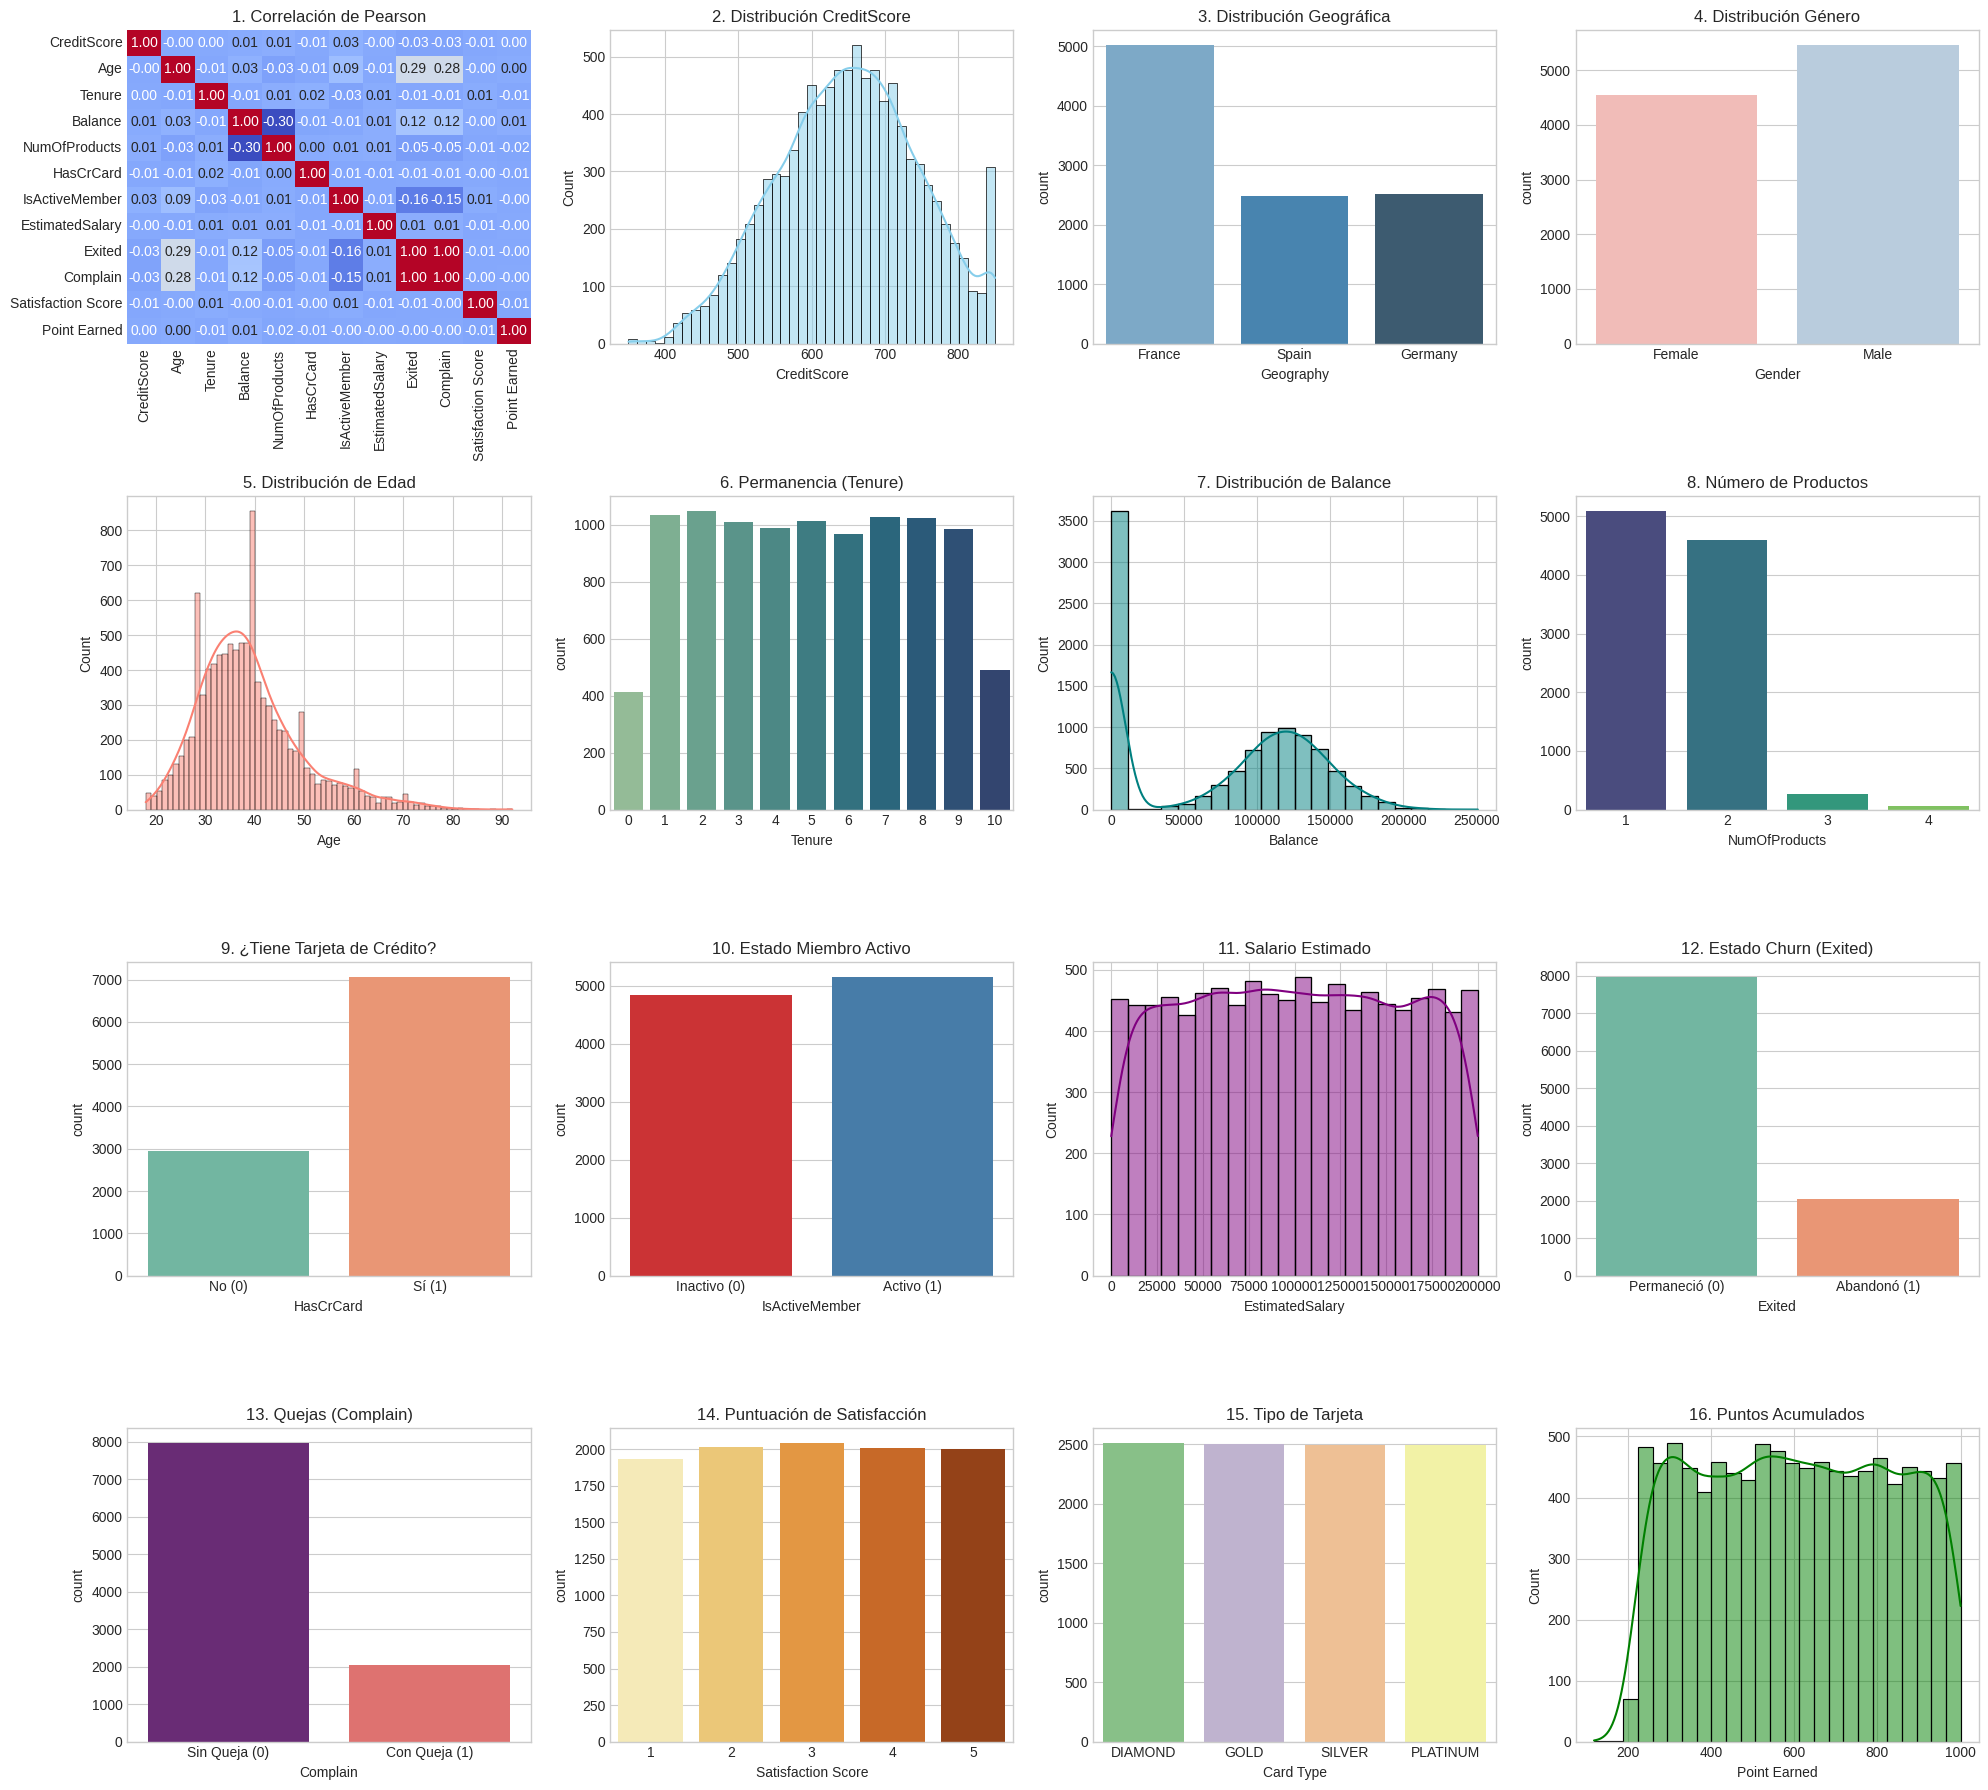

In [65]:
#@title Visualizar los datos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(4, 4, figsize=(20, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)
df['Balance'] = df['Balance'].astype(float)
# Excluir id columnas
cols_to_drop = ['index', 'RowNumber', 'CustomerId', 'Surname']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 1. Heatmap Correlación
num_cols = df_clean.select_dtypes(include=[np.number]).columns
corr = df_clean[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axes[0, 0], cbar=False)
axes[0, 0].set_title('1. Correlación de Pearson')

# 2. CreditScore
sns.histplot(df_clean['CreditScore'], kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('2. Distribución CreditScore')

# 3. Geography
sns.countplot(data=df_clean, x='Geography', ax=axes[0, 2], palette='Blues_d')
axes[0, 2].set_title('3. Distribución Geográfica')

# 4. Gender
sns.countplot(data=df_clean, x='Gender', ax=axes[0, 3], palette='Pastel1')
axes[0, 3].set_title('4. Distribución Género')

# 5. Age
sns.histplot(df_clean['Age'], kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('5. Distribución de Edad')

# 6. Tenure
sns.countplot(data=df_clean, x='Tenure', ax=axes[1, 1], palette='crest')
axes[1, 1].set_title('6. Permanencia (Tenure)')

# 7. Balance
sns.histplot(df_clean['Balance'], kde=True, ax=axes[1, 2], color='teal')
axes[1, 2].set_title('7. Distribución de Balance')

# 8. NumOfProducts
sns.countplot(data=df_clean, x='NumOfProducts', ax=axes[1, 3], palette='viridis')
axes[1, 3].set_title('8. Número de Productos')

# 9. HasCrCard
sns.countplot(data=df_clean, x='HasCrCard', ax=axes[2, 0], palette='Set2')
axes[2, 0].set_title('9. ¿Tiene Tarjeta de Crédito?')
axes[2, 0].set_xticklabels(['No (0)', 'Sí (1)'])

# 10. IsActiveMember
sns.countplot(data=df_clean, x='IsActiveMember', ax=axes[2, 1], palette='Set1')
axes[2, 1].set_title('10. Estado Miembro Activo')
axes[2, 1].set_xticklabels(['Inactivo (0)', 'Activo (1)'])

# 11. EstimatedSalary
sns.histplot(df_clean['EstimatedSalary'], kde=True, ax=axes[2, 2], color='purple')
axes[2, 2].set_title('11. Salario Estimado')

# 12. Exited
sns.countplot(data=df_clean, x='Exited', ax=axes[2, 3], palette='Set2')
axes[2, 3].set_title('12. Estado Churn (Exited)')
axes[2, 3].set_xticklabels(['Permaneció (0)', 'Abandonó (1)'])

# 13. Complain
sns.countplot(data=df_clean, x='Complain', ax=axes[3, 0], palette='magma')
axes[3, 0].set_title('13. Quejas (Complain)')
axes[3, 0].set_xticklabels(['Sin Queja (0)', 'Con Queja (1)'])

# 14. Satisfaction Score
sns.countplot(data=df_clean, x='Satisfaction Score', ax=axes[3, 1], palette='YlOrBr')
axes[3, 1].set_title('14. Puntuación de Satisfacción')

# 15. Card Type
sns.countplot(data=df_clean, x='Card Type', ax=axes[3, 2], palette='Accent')
axes[3, 2].set_title('15. Tipo de Tarjeta')

# 16. Point Earned
sns.histplot(df_clean['Point Earned'], kde=True, ax=axes[3, 3], color='green')
axes[3, 3].set_title('16. Puntos Acumulados')

plt.tight_layout()
plt.savefig('eda_summary.png', dpi=300)
plt.show()

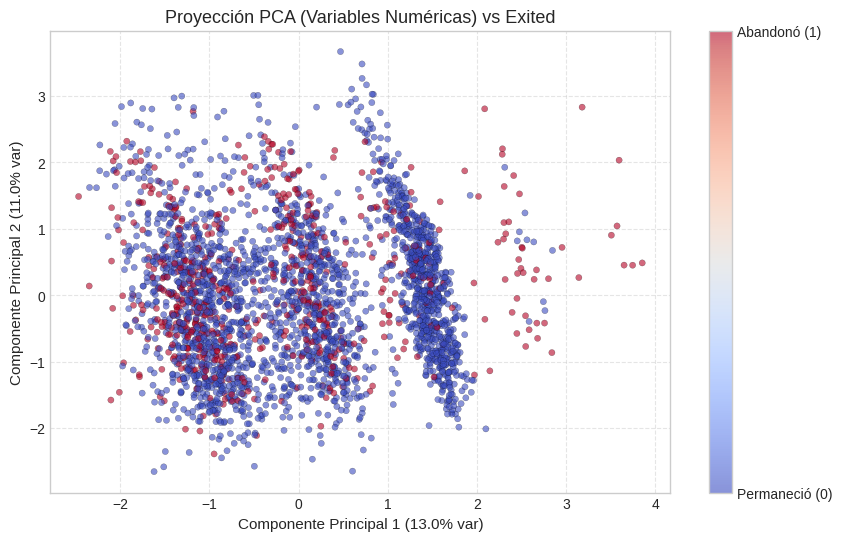

In [66]:
#@title Visualizacion Target
from sklearn.decomposition import PCA

# 1. Extracción de todas las columnas numéricas sin limpiar categóricas aún
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
            'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
            'Satisfaction Score', 'Point Earned']

X_all_num = df[num_cols].values
y_raw = df['Exited'].values

# 2. Estandarización con prepare_data
X_train_full, Y_train, X_dev_full, Y_dev, X_test_full, Y_test = prepare_data(X_all_num, y_raw)

# 3. Proyección PCA a 2 dimensiones (Se traspone para ajustar en formato m x n_x)
pca = PCA(n_components=2, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_full.T).T  # Resultado traspuesto a formato (2, m)

# 4. Visualización
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_train_pca[0], X_train_pca[1],
    c=Y_train.ravel(),
    cmap="coolwarm",
    edgecolor="k",
    linewidth=0.2,
    s=20,
    alpha=0.6
)

plt.xlabel(f"Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)", fontsize=11)
plt.ylabel(f"Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)", fontsize=11)
plt.title("Proyección PCA (Variables Numéricas) vs Exited", fontsize=13)

cbar = plt.colorbar(scatter, ticks=[0, 1])
cbar.ax.set_yticklabels(['Permaneció (0)', 'Abandonó (1)'])
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [67]:
#@title Limpieza de datos NO estandarización
# 2. Eliminación de identificadores irrelevantes
cols_to_drop = ['index', 'RowNumber', 'CustomerId', 'Surname']
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 3. Conversión explícita de tipos
if 'Balance' in df_clean.columns:
    df_clean['Balance'] = df_clean['Balance'].astype(float)

# 4. Codificación One-Hot (Geography, Gender, Card Type)
# Genera columnas binarias (0 y 1) compatibles con arreglos de NumPy
df_preprocessed = pd.get_dummies(
    df_clean,
    columns=['Geography', 'Gender', 'Card Type'],
    dtype=int
)

# 5. Reordenamiento opcional: Mantener 'Exited' como la última columna
target_col = 'Exited'
feature_cols = [col for col in df_preprocessed.columns if col != target_col]
df_preprocessed = df_preprocessed[feature_cols + [target_col]]

print(f"Dimensiones del DataFrame procesado: {df_preprocessed.shape}")
# Vista previa de las primeras filas del conjunto de datos limpio
df_preprocessed.head()

Dimensiones del DataFrame procesado: (10000, 21)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,...,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Card Type_DIAMOND,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER,Exited
0,619,42,2,0.00,1,1,1,101348.88,1,2,...,1,0,0,1,0,1,0,0,0,1
1,608,41,1,83807.86,1,0,1,112542.58,1,3,...,0,0,1,1,0,1,0,0,0,0
2,502,42,8,159660.80,3,1,0,113931.57,1,3,...,1,0,0,1,0,1,0,0,0,1
3,699,39,1,0.00,2,0,0,93826.63,0,5,...,1,0,0,1,0,0,1,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,5,...,0,0,1,1,0,0,1,0,0,0


## 2. Entrenamiento, validación y prueba


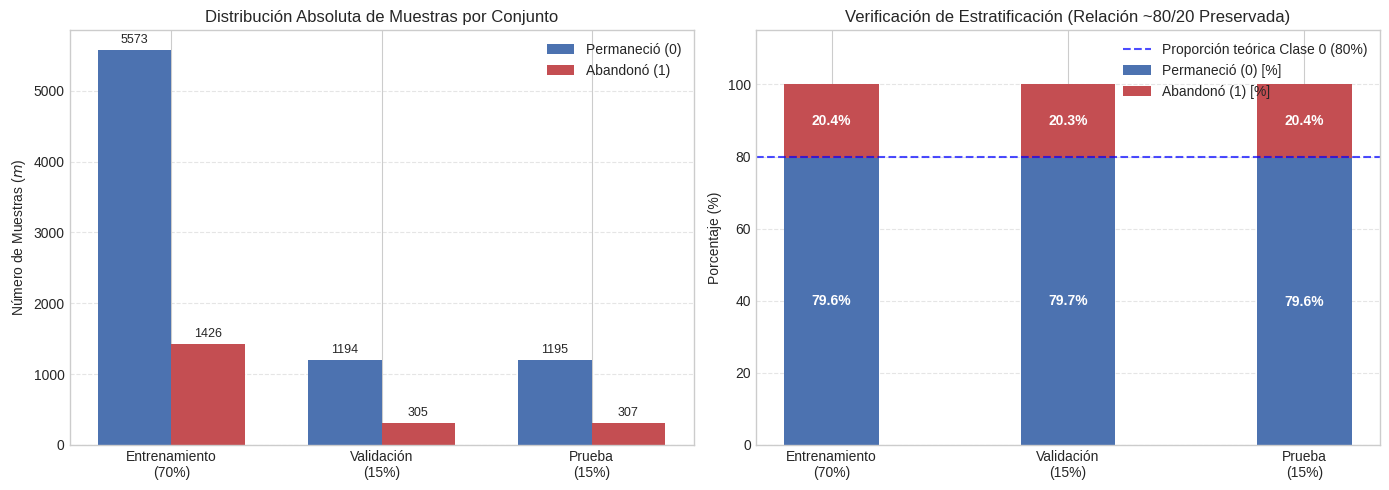

In [68]:
SEED = 42

# 1. Función para particionado estratificado en NumPy
def stratified_split_numpy(df_preprocessed, target_name='Exited', train_ratio=0.70, dev_ratio=0.15, seed=SEED):
    np.random.seed(seed)

    # Separación de X e Y
    X = df_preprocessed.drop(columns=[target_name]).values.astype(np.float64)
    y = df_preprocessed[target_name].values

    # Obtener índices por clase
    idx_0 = np.where(y == 0)[0]
    idx_1 = np.where(y == 1)[0]

    # Mezclar índices individualmente
    np.random.shuffle(idx_0)
    np.random.shuffle(idx_1)

    # Puntos de corte para Clase 0 (Permaneció)
    n0 = len(idx_0)
    n0_train = int(n0 * train_ratio)
    n0_dev = int(n0 * dev_ratio)

    # Puntos de corte para Clase 1 (Abandonó)
    n1 = len(idx_1)
    n1_train = int(n1 * train_ratio)
    n1_dev = int(n1 * dev_ratio)

    # Construcción de índices estratificados por conjunto
    train_idx = np.concatenate([idx_0[:n0_train], idx_1[:n1_train]])
    dev_idx = np.concatenate([idx_0[n0_train:n0_train+n0_dev], idx_1[n1_train:n1_train+n1_dev]])
    test_idx = np.concatenate([idx_0[n0_train+n0_dev:], idx_1[n1_train+n1_dev:]])

    # Mezcla final de cada partición
    np.random.shuffle(train_idx)
    np.random.shuffle(dev_idx)
    np.random.shuffle(test_idx)

    # Formato matricial listo para Red Neuronal: X en (n_x, m) y Y en (1, m)
    X_train, Y_train = X[train_idx].T, y[train_idx].reshape(1, -1)
    X_dev, Y_dev = X[dev_idx].T, y[dev_idx].reshape(1, -1)
    X_test, Y_test = X[test_idx].T, y[test_idx].reshape(1, -1)

    return X_train, Y_train, X_dev, Y_dev, X_test, Y_test

# Ejecución sobre el DataFrame procesado previo
X_train, Y_train, X_dev, Y_dev, X_test, Y_test = stratified_split_numpy(df_preprocessed)

# 2. Código para graficar y verificar la estratificación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sets = ['Entrenamiento\n(70%)', 'Validación\n(15%)', 'Prueba\n(15%)']
c0_counts = [np.sum(Y_train == 0), np.sum(Y_dev == 0), np.sum(Y_test == 0)]
c1_counts = [np.sum(Y_train == 1), np.sum(Y_dev == 1), np.sum(Y_test == 1)]

# Gráfico 1: Conteo absoluto de registros
x = np.arange(len(sets))
width = 0.35

rects1 = axes[0].bar(x - width/2, c0_counts, width, label='Permaneció (0)', color='#4c72b0')
rects2 = axes[0].bar(x + width/2, c1_counts, width, label='Abandonó (1)', color='#c44e52')

axes[0].set_ylabel('Número de Muestras ($m$)')
axes[0].set_title('Distribución Absoluta de Muestras por Conjunto')
axes[0].set_xticks(x)
axes[0].set_xticklabels(sets)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5, axis='y')

for rect in rects1 + rects2:
    height = rect.get_height()
    axes[0].annotate(f'{height}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

# Gráfico 2: Proporción relativa (%) para validar la preservación de la relación 80/20
c0_props = [np.mean(Y_train == 0) * 100, np.mean(Y_dev == 0) * 100, np.mean(Y_test == 0) * 100]
c1_props = [np.mean(Y_train == 1) * 100, np.mean(Y_dev == 1) * 100, np.mean(Y_test == 1) * 100]

axes[1].bar(sets, c0_props, label='Permaneció (0) [%]', color='#4c72b0', width=0.4)
axes[1].bar(sets, c1_props, bottom=c0_props, label='Abandonó (1) [%]', color='#c44e52', width=0.4)

axes[1].axhline(y=80.0, color='blue', linestyle='--', alpha=0.7, label='Proporción teórica Clase 0 (80%)')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_title('Verificación de Estratificación (Relación ~80/20 Preservada)')
axes[1].set_ylim(0, 115)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.5, axis='y')

for i in range(len(sets)):
    axes[1].text(i, c0_props[i]/2, f'{c0_props[i]:.1f}%', ha='center', va='center', color='white', fontweight='bold')
    axes[1].text(i, c0_props[i] + c1_props[i]/2, f'{c1_props[i]:.1f}%', ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Estandarización Media y desviación estándar


In [69]:
#@title Estarización Z-Score
def normalize_datasets(X_train, X_dev, X_test, eps=1e-8):
    """
    Normaliza (Z-score) las matrices de características de entrada en dimensión (n_x, m).

    Parámetros:
        X_train: Matriz de entrenamiento de dimensión (n_x, m_train)
        X_dev:   Matriz de validación de dimensión (n_x, m_dev)
        X_test:  Matriz de prueba de dimensión (n_x, m_test)
        eps:     Factor de estabilidad numérica para evitar división por cero

    Retorna:
        X_train_norm, X_dev_norm, X_test_norm, mu, sigma
    """
    # 1. Cálculo de mu y sigma EXCLUSIVAMENTE sobre el conjunto de entrenamiento
    # axis=1 promedia sobre las m_train columnas para cada una de las n_x características
    mu = np.mean(X_train, axis=1, keepdims=True)       # Dimensión: (n_x, 1)
    sigma = np.std(X_train, axis=1, keepdims=True)     # Dimensión: (n_x, 1)

    # Prevenir división por cero en características con varianza nula
    sigma = np.where(sigma == 0, eps, sigma)

    # 2. Escalado Z-score aplicado a los tres conjuntos usando únicamente mu y sigma de train
    X_train_norm = (X_train - mu) / sigma
    X_dev_norm   = (X_dev - mu) / sigma
    X_test_norm  = (X_test - mu) / sigma

    return X_train_norm, X_dev_norm, X_test_norm, mu, sigma

# Ejecución de la normalización
X_train_norm, X_dev_norm, X_test_norm, mu, sigma = normalize_datasets(X_train, X_dev, X_test)

In [70]:
#@title Verificacion
# Comprobación de dimensiones
print(f"Dimensiones X_train_norm: {X_train_norm.shape}")
print(f"Dimensiones X_dev_norm:   {X_dev_norm.shape}")
print(f"Dimensiones X_test_norm:  {X_test_norm.shape}\n")

# Comprobación de media y desviación estándar en Entrenamiento (deben ser exactas: mu ~ 0, sigma = 1)
print(f"Media en Train (primeras 5 características): {np.mean(X_train_norm, axis=1)[:5].round(4)}")
print(f"Std en Train   (primeras 5 características): {np.std(X_train_norm, axis=1)[:5].round(4)}\n")

# Comprobación en Validación (deben estar cercanas a 0 y 1, pero no ser idénticas a train)
print(f"Media en Dev   (primeras 5 características): {np.mean(X_dev_norm, axis=1)[:5].round(4)}")
print(f"Std en Dev     (primeras 5 características): {np.std(X_dev_norm, axis=1)[:5].round(4)}")

Dimensiones X_train_norm: (20, 6999)
Dimensiones X_dev_norm:   (20, 1499)
Dimensiones X_test_norm:  (20, 1502)

Media en Train (primeras 5 características): [-0.  0.  0. -0. -0.]
Std en Train   (primeras 5 características): [1. 1. 1. 1. 1.]

Media en Dev   (primeras 5 características): [ 0.0102 -0.0196  0.0176 -0.015  -0.0253]
Std en Dev     (primeras 5 características): [1.0018 0.9625 1.0113 0.9961 0.9846]


## 4. **Red Neuronal**


In [79]:
#@title Definicion de Arquitecturas
# Semilla global para reproducibilidad
SEED = 42

# Obtención dinámica del número de características reales
n_x = X_train.shape[0]

# Definición de las 3 arquitecturas adaptadas al n_x real
architectures = {
    "Pequeña": [n_x, 16, 8, 1],
    "Mediana": [n_x, 64, 32, 16, 1],
    "Amplia":  [n_x, 128, 64, 32, 1]
}

# Rango de búsqueda para selección de hiperparámetros en validación
lambda_candidates = [0.01, 0.1, 0.5, 1.0, 2.0]
keep_prob_candidates = [0.6, 0.7, 0.8, 0.9]

print(f"Características de entrada detectadas (n_x): {n_x}")

Características de entrada detectadas (n_x): 20


In [80]:
#@title Funcion de activaciones, perdida y penalizacion
def sigmoid(Z):
    """Función de activación sigmoide con acotamiento numérico."""
    Z = np.clip(Z, -500, 500)
    return 1.0 / (1.0 + np.exp(-Z))


def binary_cross_entropy(AL, Y):
    """Cálculo de la entropía cruzada binaria (BCE)."""
    AL = np.clip(AL, 1e-12, 1.0 - 1e-12)
    return float(-np.mean(Y * np.log(AL) + (1.0 - Y) * np.log(1.0 - AL)))


def initialize_he(layer_dims, seed=SEED):
    """Inicialización de He ajustada para capas con activación ReLU."""
    rng = np.random.default_rng(seed)
    params = {}
    for l in range(1, len(layer_dims)):
        n_out, n_in = layer_dims[l], layer_dims[l - 1]
        params[f"W{l}"] = rng.standard_normal((n_out, n_in)) * np.sqrt(2.0 / n_in)
        params[f"b{l}"] = np.zeros((n_out, 1))
    return params


def l2_penalty(params, m, lambd):
    """Penalización por regularización L2 sobre las matrices de pesos."""
    if lambd == 0.0:
        return 0.0
    weights = (value for key, value in params.items() if key.startswith("W"))
    return (lambd / (2.0 * m)) * sum(np.sum(W**2) for W in weights)

In [81]:
#@title forward y backpropagation
def L_model_forward(X, params, keep_prob=1.0, training=False, rng=None):
    """Propagación hacia adelante con ReLU en ocultas, Sigmoide en salida y Inverted Dropout."""
    if not (0 < keep_prob <= 1.0):
        raise ValueError("keep_prob debe pertenecer al intervalo (0, 1]")
    if rng is None:
        rng = np.random.default_rng(SEED)

    A, caches = X, []
    L = len(params) // 2

    # Capas ocultas (ReLU + Inverted Dropout)
    for l in range(1, L):
        A_prev = A
        W, b = params[f"W{l}"], params[f"b{l}"]
        Z = W @ A_prev + b
        A = np.maximum(0, Z)

        D = None
        if training and keep_prob < 1.0:
            D = rng.random(A.shape) < keep_prob
            A = (A * D) / keep_prob

        caches.append({"A_prev": A_prev, "W": W, "Z": Z, "D": D})

    # Capa de salida (Sigmoide, sin Dropout)
    A_prev = A
    W, b = params[f"W{L}"], params[f"b{L}"]
    Z = W @ A_prev + b
    AL = sigmoid(Z)
    caches.append({"A_prev": A_prev, "W": W, "Z": Z, "D": None})

    return AL, caches


def L_model_backward(AL, Y, caches, lambd=0.0, keep_prob=1.0):
    """Retropropagación calculando gradientes de BCE con regularización L2 y Dropout."""
    grads = {}
    m = Y.shape[1]
    L = len(caches)

    # Capa de salida
    cache = caches[-1]
    dZ = AL - Y
    grads[f"dW{L}"] = (dZ @ cache["A_prev"].T) / m + (lambd / m) * cache["W"]
    grads[f"db{L}"] = np.sum(dZ, axis=1, keepdims=True) / m
    dA = cache["W"].T @ dZ

    # Capas ocultas
    for l in reversed(range(1, L)):
        cache = caches[l - 1]

        if cache["D"] is not None:
            dA = (dA * cache["D"]) / keep_prob

        dZ = dA * (cache["Z"] > 0)
        grads[f"dW{l}"] = (dZ @ cache["A_prev"].T) / m + (lambd / m) * cache["W"]
        grads[f"db{l}"] = np.sum(dZ, axis=1, keepdims=True) / m
        dA = cache["W"].T @ dZ

    return grads

In [82]:
#@title Actualización, Predicción y Métricas

def update_parameters_deep(params, grads, learning_rate):
    """Actualización de pesos por Descenso de Gradiente."""
    L = len(params) // 2
    for l in range(1, L + 1):
        params[f"W{l}"] -= learning_rate * grads[f"dW{l}"]
        params[f"b{l}"] -= learning_rate * grads[f"db{l}"]
    return params


def predict_deep(params, X):
    """Inferencia binaria umbralizada en 0.5."""
    AL, _ = L_model_forward(X, params, training=False)
    return (AL >= 0.5).astype(int)


def accuracy(params, X, Y):
    """Porcentaje de clasificación correcta."""
    return 100.0 * np.mean(predict_deep(params, X) == Y)


def total_weight_norm(params):
    """Norma Frobenius total de las matrices de pesos: ||W||_F."""
    return np.sqrt(sum(np.sum(value**2) for key, value in params.items() if key.startswith("W")))

In [83]:
#@title Entrenamiento Regularizado
def train_regularized(X_train, Y_train, layer_dims, lambd=0.0,
                      keep_prob=1.0, iterations=6500,
                      learning_rate=0.03, seed=SEED):
    """Bucle de entrenamiento principal."""
    params = initialize_he(layer_dims, seed)
    rng = np.random.default_rng(seed)
    history = {"data_loss": [], "objective": []}

    m = Y_train.shape[1]

    for i in range(iterations):
        AL, caches = L_model_forward(
            X_train, params, keep_prob=keep_prob,
            training=(keep_prob < 1.0), rng=rng
        )

        data_loss = binary_cross_entropy(AL, Y_train)
        objective = data_loss + l2_penalty(params, m, lambd)

        grads = L_model_backward(
            AL, Y_train, caches, lambd=lambd, keep_prob=keep_prob
        )

        params = update_parameters_deep(params, grads, learning_rate)

        if i % 100 == 0:
            history["data_loss"].append(data_loss)
            history["objective"].append(objective)

    return params, history

In [87]:
#@title Búsqueda de Hiperparámetros
def select_best_hyperparams(X_train, Y_train, X_dev, Y_dev, layer_dims,
                            iterations=3000, learning_rate=0.001, seed=SEED):
    # 1. Selección de Lambda para L2
    best_lambda = lambda_candidates[0]
    best_dev_acc_l2 = -1.0

    for lmb in lambda_candidates:
        p, _ = train_regularized(
            X_train, Y_train, layer_dims,
            lambd=lmb, keep_prob=1.0,
            iterations=iterations, learning_rate=learning_rate, seed=seed
        )
        dev_acc = accuracy(p, X_dev, Y_dev)
        if dev_acc > best_dev_acc_l2:
            best_dev_acc_l2 = dev_acc
            best_lambda = lmb

    # 2. Selección de keep_prob para Dropout
    best_keep_prob = keep_prob_candidates[0]
    best_dev_acc_dp = -1.0

    for kp in keep_prob_candidates:
        p, _ = train_regularized(
            X_train, Y_train, layer_dims,
            lambd=0.0, keep_prob=kp,
            iterations=iterations, learning_rate=learning_rate, seed=seed
        )
        dev_acc = accuracy(p, X_dev, Y_dev)
        if dev_acc > best_dev_acc_dp:
            best_dev_acc_dp = dev_acc
            best_keep_prob = kp

    return best_lambda, best_keep_prob

In [91]:
#@title Evaluacion Final
# Contenedor global de resultados
all_architectures_results = {}

for arch_name, layer_dims in architectures.items():
    print(f"\n=======================================================")
    print(f" PROCESANDO ARQUITECTURA: {arch_name} -> {layer_dims}")
    print(f"=======================================================")

    # Búsqueda de hiperparámetros optimizados usando solo Validación
    opt_lambda, opt_keep_prob = select_best_hyperparams(
        X_train, Y_train, X_dev, Y_dev, layer_dims,
        iterations=3000, learning_rate=0.001, seed=SEED
    )

    print(f"Hiperparámetros óptimos hallados en Validación:")
    print(f"  - Lambda (L2): {opt_lambda}")
    print(f"  - Keep Prob (Dropout): {opt_keep_prob}\n")

    settings = {
        "Sin regularización": {"lambd": 0.0, "keep_prob": 1.0},
        "L2":                 {"lambd": opt_lambda, "keep_prob": 1.0},
        "Dropout":            {"lambd": 0.0, "keep_prob": opt_keep_prob},
    }

    models, histories, metrics = {}, {}, {}

    for name, cfg in settings.items():
        # Entrenamiento final con hiperparámetros seleccionados
        models[name], histories[name] = train_regularized(
            X_train, Y_train, layer_dims,
            iterations=5000, learning_rate=0.001, seed=SEED, **cfg
        )

        # Cálculo de desempeño
        train_acc = accuracy(models[name], X_train, Y_train)
        dev_acc   = accuracy(models[name], X_dev, Y_dev)

        # Evaluación ÚNICA en el conjunto de prueba
        test_acc  = accuracy(models[name], X_test, Y_test)

        gap = train_acc - dev_acc
        w_norm = total_weight_norm(models[name])

        metrics[name] = {
            "train_acc": train_acc,
            "dev_acc": dev_acc,
            "test_acc": test_acc,
            "gap": gap,
            "w_norm": w_norm
        }

        print(f"{name:20s} Train={train_acc:6.2f}% | Dev={dev_acc:6.2f}% | "
              f"Prueba (Única)={test_acc:6.2f}% | Brecha={gap:5.2f} pp | ||W||={w_norm:6.2f}")

    all_architectures_results[arch_name] = {
        "models": models,
        "histories": histories,
        "metrics": metrics
    }


 PROCESANDO ARQUITECTURA: Pequeña -> [20, 16, 8, 1]
Hiperparámetros óptimos hallados en Validación:
  - Lambda (L2): 0.01
  - Keep Prob (Dropout): 0.6

Sin regularización   Train= 79.63% | Dev= 79.65% | Prueba (Única)= 79.56% | Brecha=-0.03 pp | ||W||= 51.45
L2                   Train= 79.63% | Dev= 79.65% | Prueba (Única)= 79.56% | Brecha=-0.03 pp | ||W||= 51.45
Dropout              Train= 79.63% | Dev= 79.65% | Prueba (Única)= 79.56% | Brecha=-0.03 pp | ||W||=482.40

 PROCESANDO ARQUITECTURA: Mediana -> [20, 64, 32, 16, 1]
Hiperparámetros óptimos hallados en Validación:
  - Lambda (L2): 0.01
  - Keep Prob (Dropout): 0.6

Sin regularización   Train= 79.63% | Dev= 79.65% | Prueba (Única)= 79.56% | Brecha=-0.03 pp | ||W||=4470327454575.85
L2                   Train= 79.63% | Dev= 79.65% | Prueba (Única)= 79.56% | Brecha=-0.03 pp | ||W||=4470295475836.26
Dropout              Train= 79.63% | Dev= 79.65% | Prueba (Única)= 79.56% | Brecha=-0.03 pp | ||W||=26621083241.79

 PROCESANDO ARQUIT

In [88]:
# Prueba rápida con 1,500 iteraciones y lr=0.001
test_params, _ = train_regularized(
    X_train, Y_train, architectures["Pequeña"],
    lambd=0.0, keep_prob=1.0,
    iterations=1500, learning_rate=0.001, seed=SEED
)

preds = predict_deep(test_params, X_train)
clases_predichas, conteo = np.unique(preds, return_counts=True)

print("Distribución de clases predichas:")
for c, cnt in zip(clases_predichas, conteo):
    print(f"  Clase {c}: {cnt} muestras ({cnt / len(preds.T) * 100:.2f}%)")

Distribución de clases predichas:
  Clase 0: 6999 muestras (100.00%)


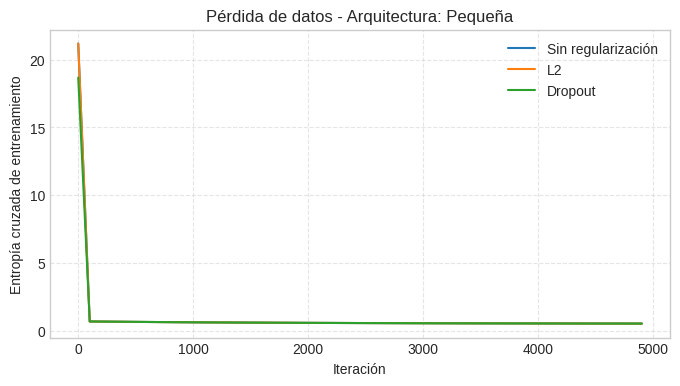

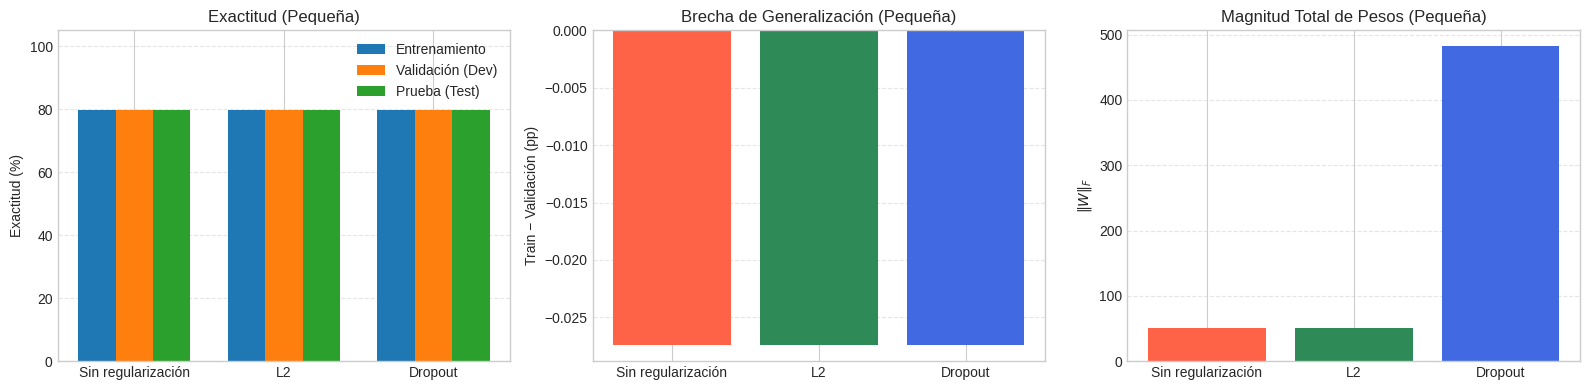

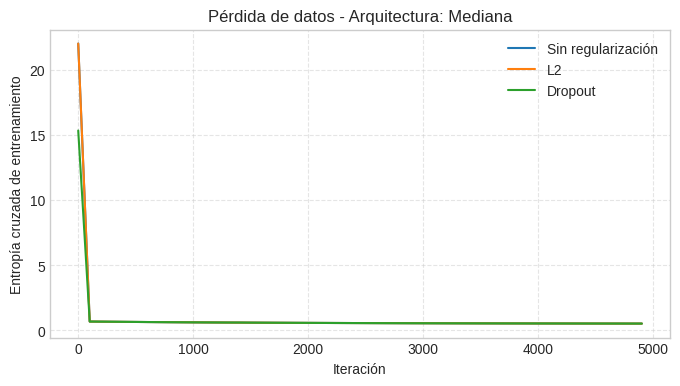

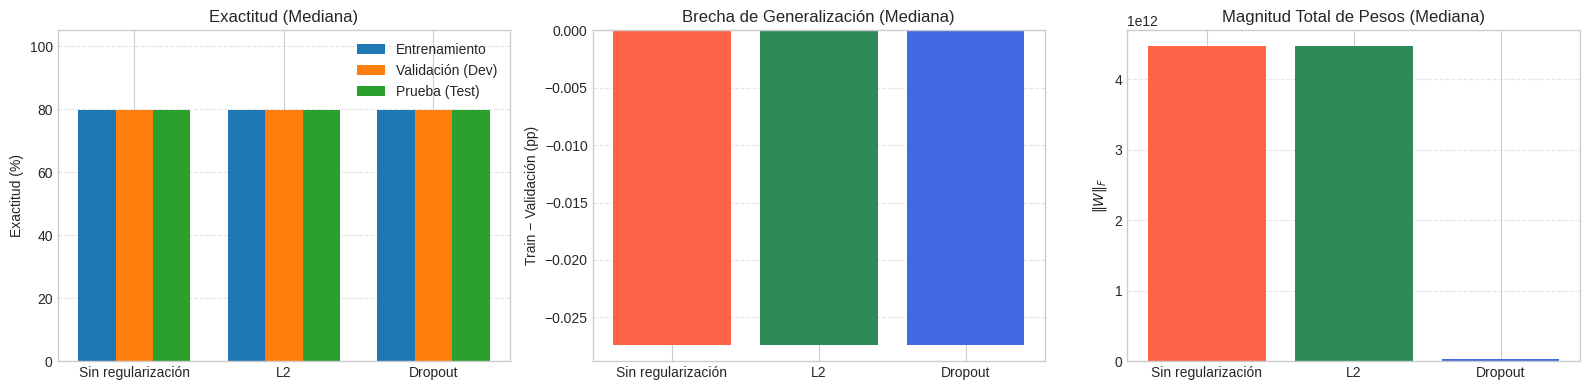

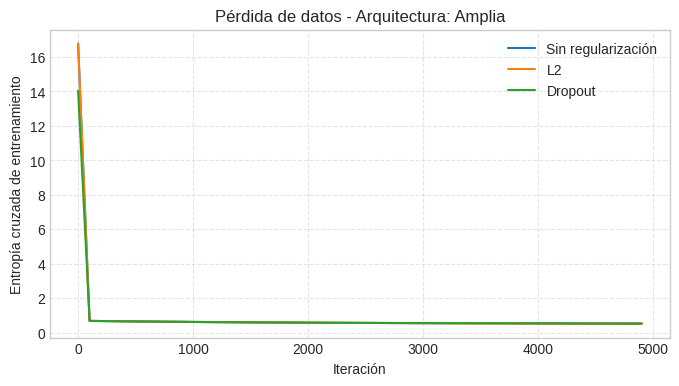

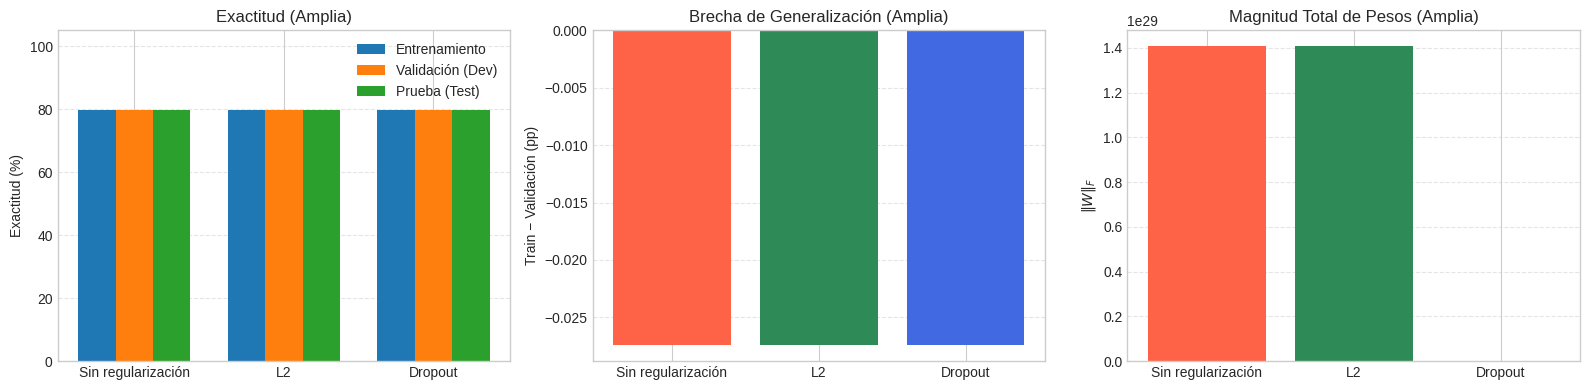

In [92]:
#@title Gráfica
for arch_name, res in all_architectures_results.items():
    models = res["models"]
    histories = res["histories"]
    metrics = res["metrics"]

    names = list(models.keys())

    # 1. Curvas de pérdida durante el entrenamiento
    plt.figure(figsize=(8, 4))
    for name, history in histories.items():
        steps = np.arange(len(history["data_loss"])) * 100
        plt.plot(steps, history["data_loss"], label=name)

    plt.xlabel("Iteración")
    plt.ylabel("Entropía cruzada de entrenamiento")
    plt.title(f"Pérdida de datos - Arquitectura: {arch_name}")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # 2. Métricas comparativas (Exactitud, Brecha y Norma de Pesos)
    train_scores = [metrics[n]["train_acc"] for n in names]
    dev_scores   = [metrics[n]["dev_acc"] for n in names]
    test_scores  = [metrics[n]["test_acc"] for n in names]
    gaps         = [metrics[n]["gap"] for n in names]
    weight_norms = [metrics[n]["w_norm"] for n in names]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    x = np.arange(len(names))
    width = 0.25

    # Subplot 0: Exactitudes
    axes[0].bar(x - width, train_scores, width, label="Entrenamiento")
    axes[0].bar(x, dev_scores, width, label="Validación (Dev)")
    axes[0].bar(x + width, test_scores, width, label="Prueba (Test)")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(names)
    axes[0].set_ylabel("Exactitud (%)")
    axes[0].set_ylim(0, 105)
    axes[0].set_title(f"Exactitud ({arch_name})")
    axes[0].legend()
    axes[0].grid(axis="y", linestyle="--", alpha=0.5)

    # Subplot 1: Brecha de Generalización
    axes[1].bar(names, gaps, color=["tomato", "seagreen", "royalblue"])
    axes[1].set_ylabel("Train − Validación (pp)")
    axes[1].set_title(f"Brecha de Generalización ({arch_name})")
    axes[1].grid(axis="y", linestyle="--", alpha=0.5)

    # Subplot 2: Magnitud de Pesos
    axes[2].bar(names, weight_norms, color=["tomato", "seagreen", "royalblue"])
    axes[2].set_ylabel(r"$\Vert W\Vert_F$")
    axes[2].set_title(f"Magnitud Total de Pesos ({arch_name})")
    axes[2].grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

## 5. Resultados
Tabla comparativa:

| Arquitectura | Método | Hiperparámetro | Train | Validación | Brecha | $\Vert W\Vert_F$ |
|---|---|---:|---:|---:|---:|---:|
|  | Sin regularización | — |  |  |  |  |
|  | L2 | $\lambda=$ |  |  |  |  |
|  | Dropout | `keep_prob=` |  |  |  |  |


## Pregunta integradora

> ¿Qué arquitectura y método de regularización ofrecen la mejor capacidad de generalización y qué resultados respaldan esta conclusión?




### curvas de pérdida


### matriz de confusión


### exactitud, precisión, recall y F1

### configuración seleccionada y resultado final en prueba.